# Reproduce Results
Loads trained checkpoints and regenerates all figures and metrics. No retraining required.

## 1. Imports and Config

In [10]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from torch.utils.data import DataLoader

# project root — adjust if needed
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.scalers       import load_scalers
from utils.splits        import subject_split
from src.dataset         import IMUDataset
from src.models.lstm     import LSTMModel
from src.models.tcn      import TCNModel
from src.models.patchtst import PatchTST
from src.evaluate        import evaluate_metrics

# ── Paths ─────────────────────────────────────────────────────────────────────
METADATA_PATH  = os.path.join(project_root, 'data', 'processed', 'metadata.csv')
SCALER_PATH    = os.path.join(project_root, 'data', 'processed', 'scalers')
CHECKPOINT_DIR = os.path.join(project_root, 'checkpoints')
RESULTS_DIR    = os.path.join(project_root, 'results')
DATA_ROOT      = os.path.join(project_root, 'data', 'matlab_exported')

VAL_SUBJECTS  = ['AB28', 'AB29', 'AB30']
TEST_SUBJECTS = ['AB25', 'AB27']

IMU_COLS = [
    'foot_Accel_X',  'foot_Accel_Y',  'foot_Accel_Z',
    'foot_Gyro_X',   'foot_Gyro_Y',   'foot_Gyro_Z',
    'shank_Accel_X', 'shank_Accel_Y', 'shank_Accel_Z',
    'shank_Gyro_X',  'shank_Gyro_Y',  'shank_Gyro_Z',
    'thigh_Accel_X', 'thigh_Accel_Y', 'thigh_Accel_Z',
    'thigh_Gyro_X',  'thigh_Gyro_Y',  'thigh_Gyro_Z',
    'trunk_Accel_X', 'trunk_Accel_Y', 'trunk_Accel_Z',
    'trunk_Gyro_X',  'trunk_Gyro_Y',  'trunk_Gyro_Z',
]

IK_COLS = [
    'hip_flexion_r',
    'hip_adduction_r',
    'hip_rotation_r',
    'knee_angle_r',
    'ankle_angle_r',
]

JOINT_LABELS = {
    'hip_flexion_r':   'Hip Flexion',
    'hip_adduction_r': 'Hip Adduction',
    'hip_rotation_r':  'Hip Rotation',
    'knee_angle_r':    'Knee Angle',
    'ankle_angle_r':   'Ankle Angle',
}

WINDOW_SIZE = 200
STRIDE      = 100
BATCH_SIZE  = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Load Scalers, Metadata and Models

In [11]:
imu_scaler, ik_scaler = load_scalers(SCALER_PATH)
print('Scalers loaded.')

metadata = pd.read_csv(METADATA_PATH)
train_meta, val_meta, test_meta = subject_split(
    metadata, VAL_SUBJECTS, TEST_SUBJECTS)
print(f'Test subjects: {test_meta["subject_id"].unique().tolist()}')

test_ds = IMUDataset(test_meta, WINDOW_SIZE, STRIDE,
                     IMU_COLS, IK_COLS, imu_scaler, ik_scaler)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=0)

input_size  = len(IMU_COLS)
output_size = len(IK_COLS)

lstm_model = LSTMModel(input_size=input_size, output_size=output_size)
lstm_model.load_state_dict(torch.load(
    os.path.join(CHECKPOINT_DIR, 'lstm_best.pt'),
    map_location=device, weights_only=True))
lstm_model = lstm_model.to(device)

tcn_model = TCNModel(input_size=input_size, output_size=output_size)
tcn_model.load_state_dict(torch.load(
    os.path.join(CHECKPOINT_DIR, 'tcn_best.pt'),
    map_location=device, weights_only=True))
tcn_model = tcn_model.to(device)

patchtst_model = PatchTST(input_size=input_size, output_size=output_size)
patchtst_model.load_state_dict(torch.load(
    os.path.join(CHECKPOINT_DIR, 'patchtst_best.pt'),
    map_location=device, weights_only=True))
patchtst_model = patchtst_model.to(device)

models = {
    'LSTM':     lstm_model,
    'TCN':      tcn_model,
    'PatchTST': patchtst_model,
}
print('All models loaded.')

Scalers loaded.
Test subjects: ['AB25', 'AB27']
All models loaded.


## 3. RMSE Results Table

In [12]:
all_rmse  = {}
all_preds = {}

for name, model in models.items():
    rmse, preds, targets = evaluate_metrics(
        model, test_loader, ik_scaler, IK_COLS, device)
    all_rmse[name]  = rmse
    all_preds[name] = preds

rows = []
for model_name, rmse_dict in all_rmse.items():
    row = {'Model': model_name}
    for joint, val in rmse_dict.items():
        row[JOINT_LABELS[joint]] = round(val, 2)
    row['Mean'] = round(np.mean(list(rmse_dict.values())), 2)
    rows.append(row)

results_df = pd.DataFrame(rows).set_index('Model')
print('\nRMSE (degrees):')
display(results_df)


Joint                  RMSE (°)
--------------------------------
hip_flexion_r              6.38
hip_adduction_r            5.04
hip_rotation_r             7.05
knee_angle_r               5.87
ankle_angle_r              4.16
--------------------------------
Mean                       5.70

Joint                  RMSE (°)
--------------------------------
hip_flexion_r              7.21
hip_adduction_r            4.66
hip_rotation_r             6.66
knee_angle_r               6.54
ankle_angle_r              3.39
--------------------------------
Mean                       5.69

Joint                  RMSE (°)
--------------------------------
hip_flexion_r              6.87
hip_adduction_r            4.80
hip_rotation_r             7.27
knee_angle_r               6.32
ankle_angle_r              3.90
--------------------------------
Mean                       5.83

RMSE (degrees):


,Hip Flexion,Hip Adduction,Hip Rotation,Knee Angle,Ankle Angle,Mean
Model,,,,,,
LSTM,6.38,5.04,7.05,5.87,4.16,5.70
TCN,7.21,4.66,6.66,6.54,3.39,5.69
PatchTST,6.87,4.80,7.27,6.32,3.90,5.83


## 4. Training Curves

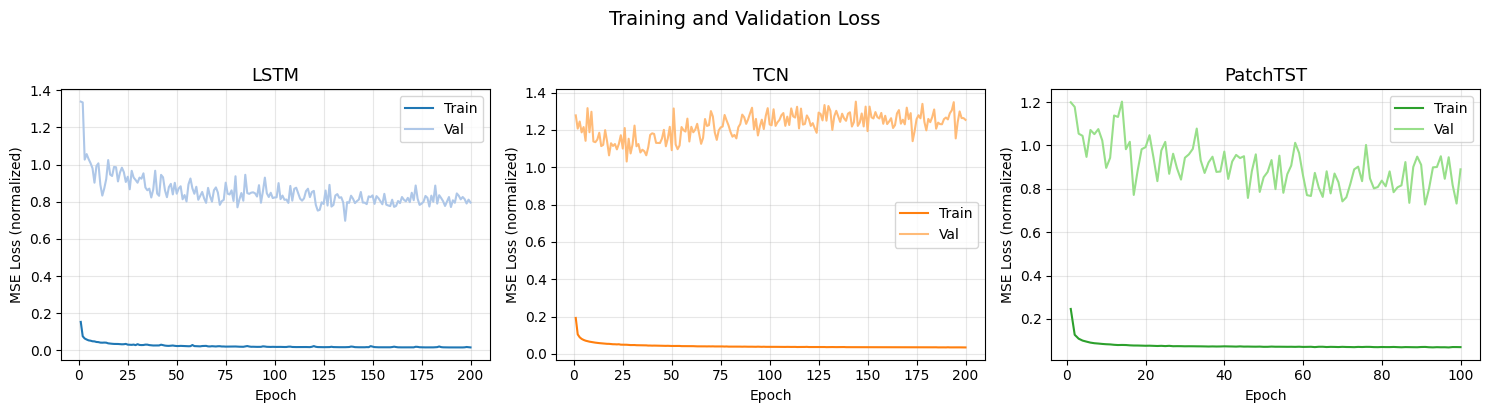

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_names = ['lstm', 'tcn', 'patchtst']
titles      = ['LSTM', 'TCN', 'PatchTST']
colors      = [('#1f77b4', '#aec7e8'), ('#ff7f0e', '#ffbb78'), ('#2ca02c', '#98df8a')]

for ax, mname, title, (c_train, c_val) in zip(axes, model_names, titles, colors):
    train_losses = np.load(os.path.join(RESULTS_DIR, f'{mname}_train_losses.npy'))
    val_losses   = np.load(os.path.join(RESULTS_DIR, f'{mname}_val_losses.npy'))
    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, color=c_train, label='Train', linewidth=1.5)
    ax.plot(epochs, val_losses,   color=c_val,   label='Val',   linewidth=1.5)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss (normalized)')
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Training and Validation Loss', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


## 5. Gait Cycle Functions

In [14]:
def run_inference_on_trial(model, imu_path, ik_path,
                           imu_cols, ik_cols,
                           imu_scaler, ik_scaler, device):
    imu_df = pd.read_csv(imu_path)
    ik_df  = pd.read_csv(ik_path)

    time = imu_df['Header'].values
    imu  = imu_df[imu_cols].values.astype(np.float32)
    ik   = ik_df[ik_cols].values.astype(np.float32)

    n    = min(len(imu), len(ik))
    time = time[:n]
    imu  = imu_scaler.transform(imu[:n]).astype(np.float32)
    ik   = ik[:n]

    pred_sum   = np.zeros((n, len(ik_cols)), np.float64)
    pred_count = np.zeros((n, len(ik_cols)), np.float64)

    model.eval()
    with torch.no_grad():
        for start in range(0, n - WINDOW_SIZE + 1, STRIDE):
            end  = start + WINDOW_SIZE
            x    = torch.from_numpy(imu[start:end]).unsqueeze(0).to(device)
            pred = model(x).squeeze(0).cpu().numpy()
            pred = ik_scaler.inverse_transform(pred)
            pred_sum[start:end]   += pred
            pred_count[start:end] += 1

    valid = pred_count[:, 0] > 0
    prediction = np.full((n, len(ik_cols)), np.nan)
    prediction[valid] = pred_sum[valid] / pred_count[valid]

    return time, prediction, ik


def get_gait_cycle_indices(gc_df):
    hs = gc_df['HeelStrike'].values
    resets = np.where(np.diff(hs) < -50)[0] + 1
    boundaries = np.concatenate([[0], resets, [len(hs)]])
    cycles = []
    for i in range(len(boundaries) - 1):
        start = boundaries[i]
        end   = boundaries[i + 1]
        if end - start > 10:
            cycles.append((start, end))
    return cycles


def segment_gait_cycles(pred, true, gc_df, n_points=101):
    cycles_pred, cycles_true = [], []
    pct_out = np.linspace(0, 100, n_points)

    for start, end in get_gait_cycle_indices(gc_df):
        pct_seg  = gc_df['HeelStrike'].values[start:end]
        pred_seg = pred[start:end]
        true_seg = true[start:end]

        if np.any(np.isnan(pred_seg)):
            continue

        interp_pred = np.zeros((n_points, pred_seg.shape[1]))
        interp_true = np.zeros((n_points, true_seg.shape[1]))

        for j in range(pred_seg.shape[1]):
            f_pred = interp1d(pct_seg, pred_seg[:, j],
                             kind='linear', bounds_error=False,
                             fill_value='extrapolate')
            f_true = interp1d(pct_seg, true_seg[:, j],
                             kind='linear', bounds_error=False,
                             fill_value='extrapolate')
            interp_pred[:, j] = f_pred(pct_out)
            interp_true[:, j] = f_true(pct_out)

        cycles_pred.append(interp_pred)
        cycles_true.append(interp_true)

    if not cycles_pred:
        return None, None, None, None

    cycles_pred = np.stack(cycles_pred)
    cycles_true = np.stack(cycles_true)

    return (cycles_pred.mean(axis=0), cycles_pred.std(axis=0),
            cycles_true.mean(axis=0), cycles_true.std(axis=0))


print('Gait cycle functions defined.')

Gait cycle functions defined.


## 6. Gait Cycle Plot

In [15]:
TEST_SUBJECT = 'AB25'   # change to AB27 for other test subject

subject_meta = test_meta[test_meta['subject_id'] == TEST_SUBJECT]
sample_row   = subject_meta.iloc[0]

imu_path   = sample_row['imu_path']
ik_path    = sample_row['ik_path']
trial_name = sample_row['trial_id']

gc_path = imu_path.replace(
    os.sep + 'imu' + os.sep,
    os.sep + 'gcRight' + os.sep
)

gc_df = pd.read_csv(gc_path)
print(f'Subject  : {TEST_SUBJECT}')
print(f'Trial    : {trial_name}')
print(f'GC rows  : {len(gc_df)}')
print(f'Cycles detected: {len(get_gait_cycle_indices(gc_df))}')

Subject  : AB25
Trial    : Treadmill_01_01
GC rows  : 28591
Cycles detected: 131


## 7. Run Inference and Segment Gait Cycles

In [16]:
pct = np.linspace(0, 100, 101)
gc_results = {}

for model_name, model in models.items():
    time, pred, true = run_inference_on_trial(
        model, imu_path, ik_path,
        IMU_COLS, IK_COLS,
        imu_scaler, ik_scaler, device)

    mean_pred, std_pred, mean_true, std_true = segment_gait_cycles(
        pred, true, gc_df)

    gc_results[model_name] = {
        'mean_pred': mean_pred,
        'std_pred':  std_pred,
        'mean_true': mean_true,
        'std_true':  std_true,
    }
    print(f'{model_name} done.')

c:\Users\Titus\anaconda3\envs\DLcourse\lib\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\Titus\anaconda3\envs\DLcourse\lib\site-packages\scipy\interpolate\_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


LSTM done.


c:\Users\Titus\anaconda3\envs\DLcourse\lib\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\Titus\anaconda3\envs\DLcourse\lib\site-packages\scipy\interpolate\_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


TCN done.
PatchTST done.


c:\Users\Titus\anaconda3\envs\DLcourse\lib\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\Titus\anaconda3\envs\DLcourse\lib\site-packages\scipy\interpolate\_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


## 8. Overlaid Gait Cycle Plot

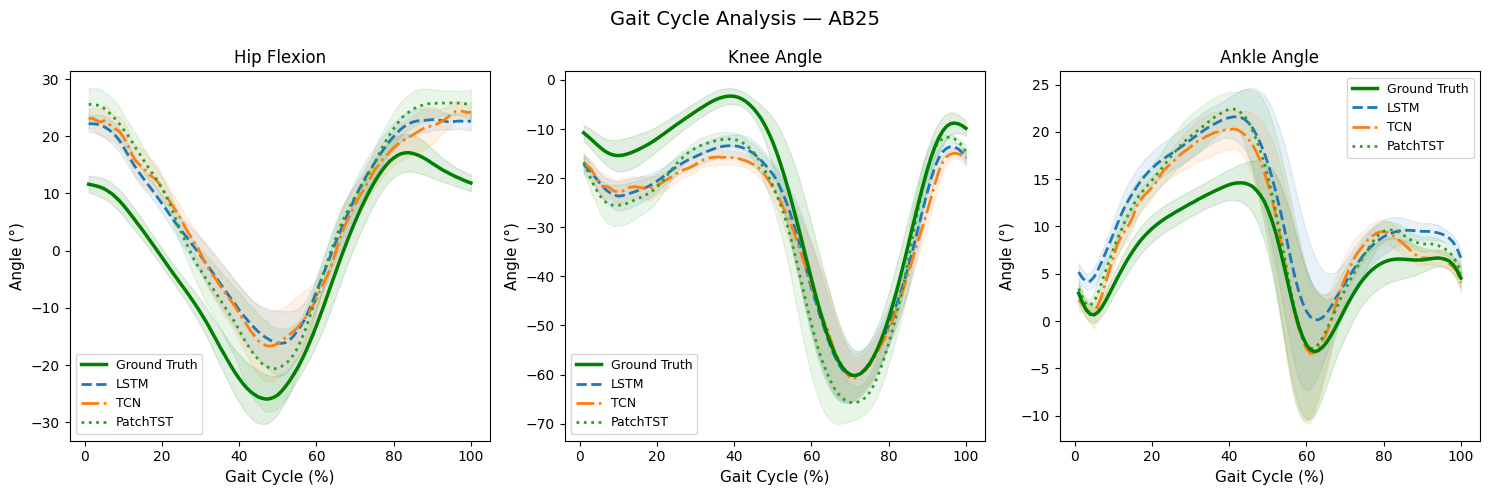

In [23]:
PLOT_JOINTS  = ['hip_flexion_r', 'knee_angle_r', 'ankle_angle_r']
PLOT_MODELS  = ['LSTM', 'TCN', 'PatchTST']
MODEL_COLORS = {'LSTM': '#1f77b4', 'TCN': '#ff7f0e', 'PatchTST': '#2ca02c'}
MODEL_LS     = {'LSTM': '--',      'TCN': '-.',       'PatchTST': ':'}

fig, axes = plt.subplots(1, len(PLOT_JOINTS),
                         figsize=(5 * len(PLOT_JOINTS), 5))

for col_j, joint in enumerate(PLOT_JOINTS):
    ax    = axes[col_j]
    j_idx = IK_COLS.index(joint)

    # ground truth — plot once
    mean_t = gc_results['LSTM']['mean_true'][:, j_idx]
    std_t  = gc_results['LSTM']['std_true'][:, j_idx]
    ax.plot(pct, mean_t, color='green', lw=2.5,
            label='Ground Truth', zorder=5)
    ax.fill_between(pct, mean_t - std_t, mean_t + std_t,
                    color='green', alpha=0.12)

    # each model
    for model_name in PLOT_MODELS:
        res    = gc_results[model_name]
        color  = MODEL_COLORS[model_name]
        ls     = MODEL_LS[model_name]
        mean_p = res['mean_pred'][:, j_idx]
        std_p  = res['std_pred'][:, j_idx]
        ax.plot(pct, mean_p, color=color, lw=2,
                ls=ls, label=model_name, zorder=4)
        ax.fill_between(pct, mean_p - std_p, mean_p + std_p,
                        color=color, alpha=0.10)

    ax.set_xlabel('Gait Cycle (%)', fontsize=11)
    ax.set_ylabel('Angle (°)', fontsize=11)
    ax.set_title(JOINT_LABELS[joint], fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle(f'Gait Cycle Analysis — {TEST_SUBJECT}', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'gait_cycle_overlaid.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 9. Learning Curves

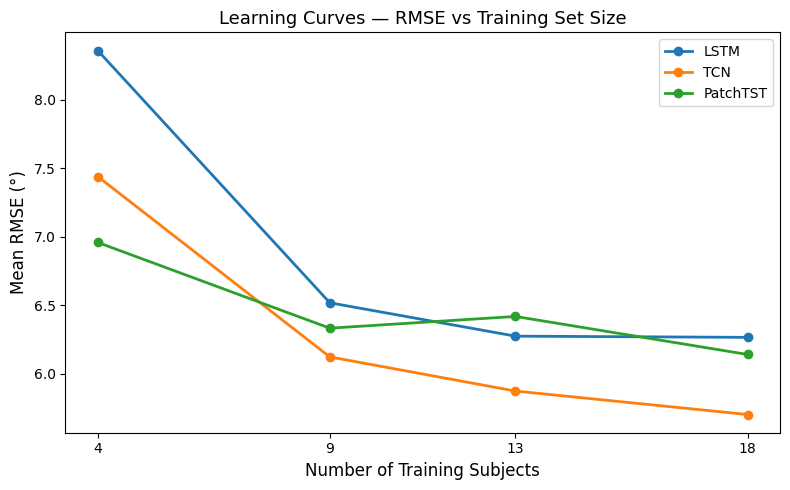

,fraction,LSTM,TCN,PatchTST
0,0.25,8.359584,7.439948,6.958779
1,0.50,6.518144,6.123030,6.332727
2,0.75,6.274514,5.873728,6.418366
3,1.00,6.265783,5.702459,6.140887


In [25]:
lc_path = os.path.join(RESULTS_DIR, 'learning_curves.csv')

lc_df = pd.read_csv(lc_path)
n_subjects = (lc_df['fraction'] * 18).astype(int)
colors = {'LSTM': '#1f77b4', 'TCN': '#ff7f0e', 'PatchTST': '#2ca02c'}

fig, ax = plt.subplots(figsize=(8, 5))
for model_name, color in colors.items():
    if model_name in lc_df.columns:
        ax.plot(n_subjects, lc_df[model_name],
                marker='o', label=model_name,
                color=color, linewidth=2)

ax.set_xlabel('Number of Training Subjects', fontsize=12)
ax.set_ylabel('Mean RMSE (°)', fontsize=12)
ax.set_title('Learning Curves — RMSE vs Training Set Size', fontsize=13)
ax.set_xticks(n_subjects)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'learning_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
display(lc_df)

## 10. TCN Augmentation Comparison

In [ ]:
aug_ckpt = os.path.join(CHECKPOINT_DIR, 'tcn_aug_best.pt')

tcn_aug_model = TCNModel(input_size=input_size, output_size=output_size)
tcn_aug_model.load_state_dict(torch.load(
    aug_ckpt, map_location=device, weights_only=True))
tcn_aug_model = tcn_aug_model.to(device)

aug_rmse, _, _ = evaluate_metrics(
    tcn_aug_model, test_loader, ik_scaler, IK_COLS, device)

print(f'\n{"Joint":<20} {"TCN":>10} {"TCN+Aug":>10}')
print('-' * 42)
for joint in IK_COLS:
    tcn_val = all_rmse['TCN'][joint]
    aug_val = aug_rmse[joint]
    print(f'{joint:<20} {tcn_val:>10.2f} {aug_val:>10.2f}')
mean_tcn = np.mean(list(all_rmse['TCN'].values()))
mean_aug = np.mean(list(aug_rmse.values()))
print('-' * 42)
print(f'{"Mean":<20} {mean_tcn:>10.2f} {mean_aug:>10.2f}')



Joint                  RMSE (°)
--------------------------------
hip_flexion_r              6.98
hip_adduction_r            4.23
hip_rotation_r             6.58
knee_angle_r               5.65
ankle_angle_r              3.47
--------------------------------
Mean                       5.38

Joint                       TCN    TCN+Aug
------------------------------------------
hip_flexion_r              7.21       6.98
hip_adduction_r            4.66       4.23
hip_rotation_r             6.66       6.58
knee_angle_r               6.54       5.65
ankle_angle_r              3.39       3.47
------------------------------------------
Mean                       5.69       5.38
